# **Insurance Claim Prediction with Highly Imbalanced Data**

This project focuses on predicting insurance claims using machine learning on a highly imbalanced dataset.

The workflow includes data exploration, preprocessing, train-test splitting, random oversampling of the training data, Random Forest classification, and model evaluation.

Because the target variable is highly imbalanced, the model is evaluated using precision, recall, F1-score, and a confusion matrix in addition to accuracy.

<u>Class Imbalance</u>


The target variable (`claim_status`) is highly imbalanced, with significantly fewer claim cases than non-claim cases.

This can cause the model to favor the majority class. Therefore, class imbalance is addressed during training and evaluated using metrics beyond accuracy.

**Data Dictionary**



| Column Name | Description |
|---|---|
| policy_id | Unique identifier for the insurance policy |
| subscription_length | Length of the insurance subscription |
| vehicle_age | Age of the vehicle |
| customer_age | Age of the customer |
| region_code | Code representing the region |
| region_density | Population density of the region |
| segment | Customer segment |
| model | Vehicle model |
| fuel_type | Type of fuel used by the vehicle |
| max_torque | Maximum engine torque |
| max_power | Maximum engine power |
| engine_type | Type of engine |
| airbags | Number of airbags |
| is_esc | Indicates whether the vehicle has Electronic Stability Control (ESC) |
| is_adjustable_steering | Indicates whether the steering wheel is adjustable |
| is_tpms | Indicates whether the vehicle has a Tire Pressure Monitoring System (TPMS) |
| is_parking_sensors | Indicates whether the vehicle has parking sensors |
| is_parking_camera | Indicates whether the vehicle has a parking camera |
| rear_brakes_type | Type of rear brakes |
| displacement | Engine displacement |
| cylinder | Number of engine cylinders |
| transmission_type | Type of transmission |
| steering_type | Type of steering mechanism |
| turning_radius | Turning radius of the vehicle |
| length | Length of the vehicle |
| width | Width of the vehicle |
| gross_weight | Gross vehicle weight |
| is_front_fog_lights | Indicates whether the vehicle has front fog lights |
| is_rear_window_wiper | Indicates whether the vehicle has a rear window wiper |
| is_rear_window_washer | Indicates whether the vehicle has a rear window washer |
| is_rear_window_defogger | Indicates whether the vehicle has a rear window defogger |
| is_brake_assist | Indicates whether the vehicle has brake assist |
| is_power_door_locks | Indicates whether the vehicle has power door locks |
| is_central_locking | Indicates whether the vehicle has central locking |
| is_power_steering | Indicates whether the vehicle has power steering |
| is_driver_seat_height_adjustable | Indicates whether the driver's seat height is adjustable |
| is_day_night_rear_view_mirror | Indicates whether the rear-view mirror has day/night adjustment |
| is_ecw | Indicates whether the vehicle has ECW |
| is_speed_alert | Indicates whether the vehicle has a speed alert system |
| ncap_rating | NCAP safety rating of the vehicle |
| claim_status | Target variable indicating whether an insurance claim was made |

#
<img src='https://miro.medium.com/v2/resize:fit:725/0*49LgGsY4l09sNwcR.png' width='900'>
<a href='https://amanxai.com/2024/04/01/classification-on-imbalanced-data-using-python/?utm_source=chatgpt.com' target=_blank><br>
Click here for the dataset </a>

**Import Libraries**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df=pd.read_csv('Insurance claims data.csv')

 **Exploratory Data Analysis**

In [4]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  str    
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  str    
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  str    
 7   model                             58592 non-null  str    
 8   fuel_type                         58592 non-null  str    
 9   max_torque                        58592 non-null  str    
 10  max_power                         58592 non-null  str    
 11  engine_type                       58592 non-null  str    
 12  airbags        

In [6]:
df.isnull().sum()

policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width                               0
gross_weight

In [7]:
df.describe()

,subscription_length,vehicle_age,customer_age,region_density,airbags,displacement,cylinder,turning_radius,length,width,gross_weight,ncap_rating,claim_status
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000
mean,6.111688,1.388473,44.823935,18826.858667,3.137066,1162.355851,3.626963,4.852893,3850.476891,1672.233667,1385.276813,1.759950,0.063968
std,4.142790,1.134413,6.935604,17660.174792,1.832641,266.304786,0.483616,0.228061,311.457119,112.089135,212.423085,1.389576,0.244698
min,0.000000,0.000000,35.000000,290.000000,1.000000,796.000000,3.000000,4.500000,3445.000000,1475.000000,1051.000000,0.000000,0.000000
25%,2.100000,0.400000,39.000000,6112.000000,2.000000,796.000000,3.000000,4.600000,3445.000000,1515.000000,1185.000000,0.000000,0.000000
50%,5.700000,1.200000,44.000000,8794.000000,2.000000,1197.000000,4.000000,4.800000,3845.000000,1735.000000,1335.000000,2.000000,0.000000
75%,10.400000,2.200000,49.000000,27003.000000,6.000000,1493.000000,4.000000,5.000000,3995.000000,1755.000000,1510.000000,3.000000,0.000000
max,14.000000,20.000000,75.000000,73430.000000,6.000000,1498.000000,4.000000,5.200000,4300.000000,1811.000000,1720.000000,5.000000,1.000000


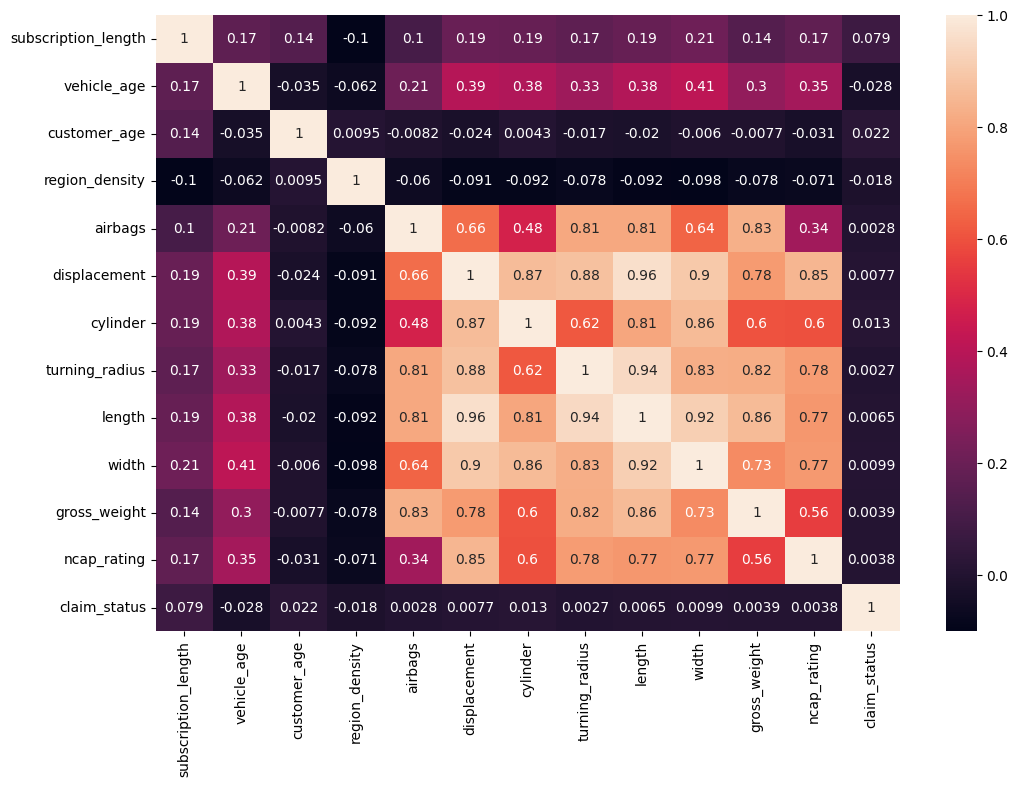

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True);

**Data Visualization**

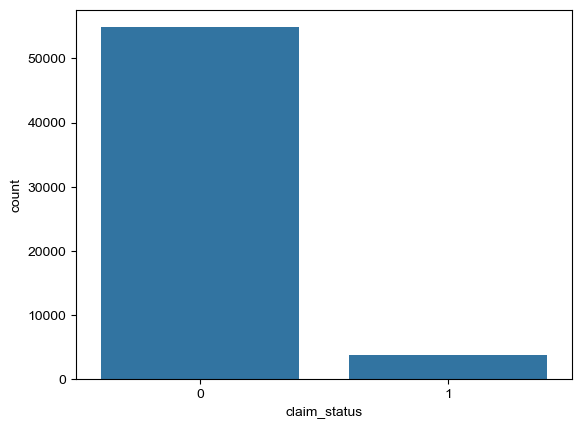

In [31]:
# Distribution of Claim Status
sns.countplot(x=df['claim_status']);

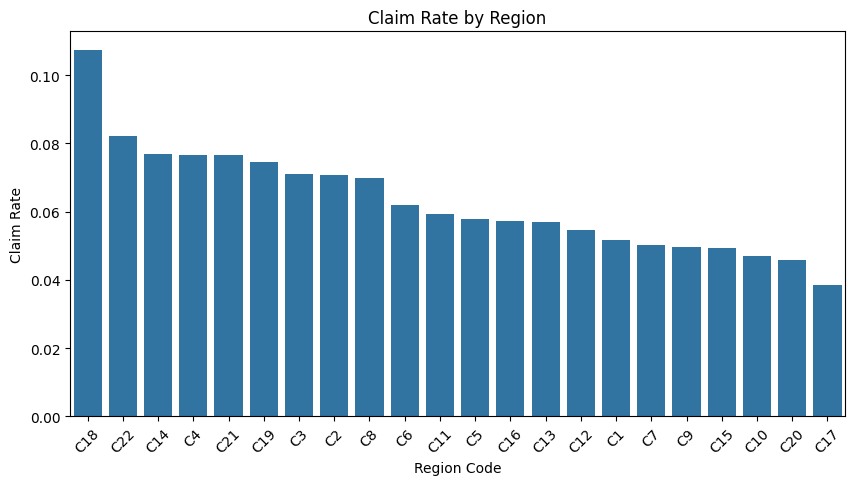

In [22]:
# Claim Rate by Region

claim_rate_by_region = (
    df.groupby("region_code")["claim_status"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=claim_rate_by_region.index,
    y=claim_rate_by_region.values
)

plt.title("Claim Rate by Region")
plt.xlabel("Region Code")
plt.ylabel("Claim Rate")
plt.xticks(rotation=45)
plt.show()

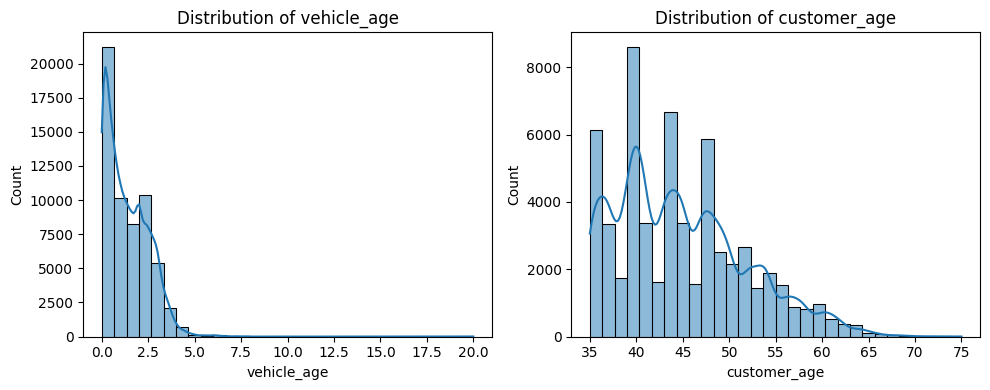

In [23]:
# Age Distributions

numerical_columns = ["vehicle_age", "customer_age"]

plt.figure(figsize=(10, 4))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, 2, i)
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

**Data Preparation**

The `policy_id` column is a unique identifier and is not used as a predictive feature.  
Categorical variables are encoded so they can be used by the machine learning model.

In [27]:
from sklearn.preprocessing import LabelEncoder

# Remove unique ID
model_df = df.drop("policy_id", axis=1).copy()

# Encode categorical columns
categorical_columns = model_df.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    model_df[column] = LabelEncoder().fit_transform(model_df[column])

In [28]:
# Features and target
x = model_df.drop("claim_status", axis=1)
y = model_df["claim_status"]

*Train-Test Split*

The dataset is split before oversampling.  
Oversampling will be applied only to the training data, while the test data remains unchanged.

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

**Handling Class Imbalance**

The minority class contains significantly fewer observations.  
Therefore, oversampling is applied **only to the training data** to create a more balanced dataset.

In [30]:
from sklearn.utils import resample

# Combine training data
train_df = pd.concat([x_train, y_train], axis=1)

# Separate the classes
majority = train_df[train_df["claim_status"] == 0]
minority = train_df[train_df["claim_status"] == 1]

# Oversample minority class
minority = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Combine both classes
train_balanced = pd.concat([majority, minority])

In [31]:
x_train_balanced = train_balanced.drop("claim_status", axis=1)
y_train_balanced = train_balanced["claim_status"]

y_train_balanced.value_counts()

claim_status
0    38390
1    38390
Name: count, dtype: int64

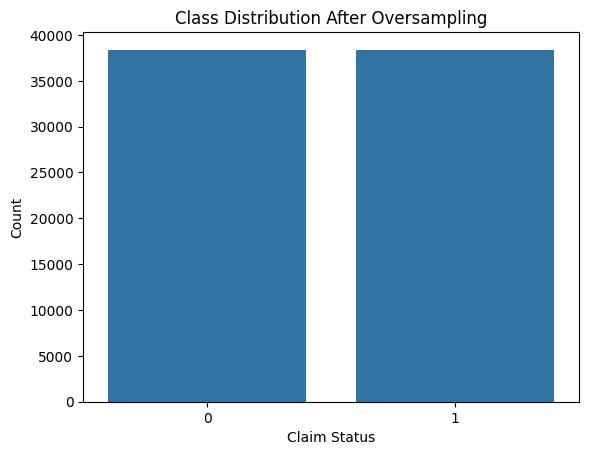

In [32]:
sns.countplot(x="claim_status", data=train_balanced)

plt.title("Class Distribution After Oversampling")
plt.xlabel("Claim Status")
plt.ylabel("Count")
plt.show()

**Model Training**

A Random Forest classifier is trained using the balanced training dataset

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(x_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

**Model Evaluation**

The model is evaluated on the original, untouched test dataset

Precision, recall and F1-score are especially important because the dataset is highly imbalanced

In [36]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9129593810444874
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     16454
           1       0.10      0.04      0.06      1124

    accuracy                           0.91     17578
   macro avg       0.52      0.51      0.51     17578
weighted avg       0.88      0.91      0.90     17578



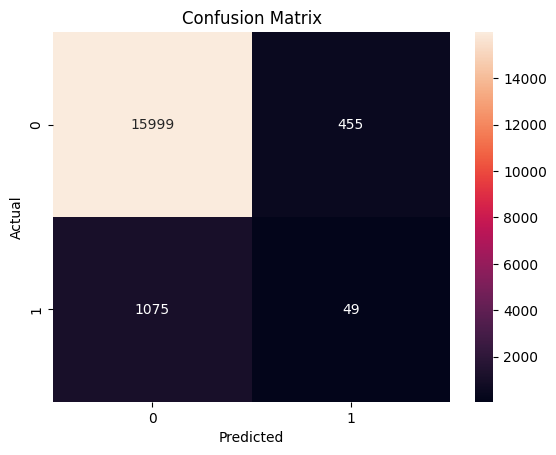

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The model achieves a high overall accuracy, but it detects only a small proportion of actual claim cases.  
Therefore, accuracy alone is not sufficient for evaluating this imbalanced classification problem.

**Feature Importance**

Feature importance shows which variables contributed most to the Random Forest predictions

In [40]:
feature_importance = pd.DataFrame({
    "Feature": x_train_balanced.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,subscription_length,0.372493
2,customer_age,0.240903
1,vehicle_age,0.211002
4,region_density,0.075767
3,region_code,0.075428
23,length,0.002356
6,model,0.002038
18,displacement,0.001992
24,width,0.001550
25,gross_weight,0.001478


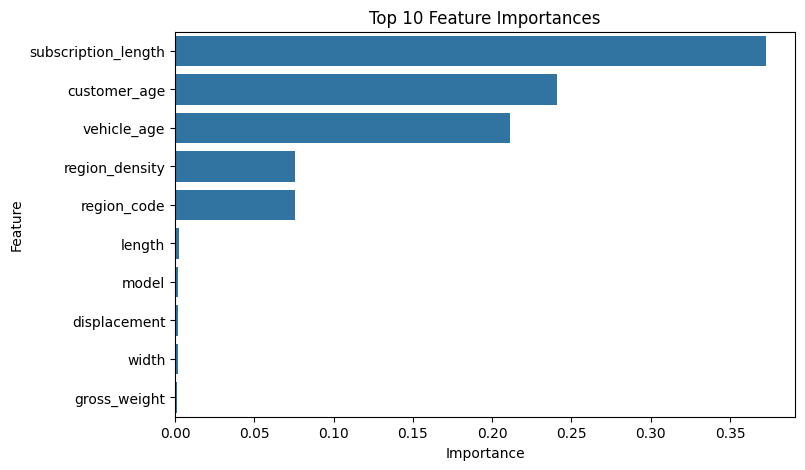

In [41]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()

#####
**Summary**

This project demonstrates how class imbalance can be handled in an insurance claim classification problem.

The data was first split into training and test sets. Random oversampling was then applied only to the training data to balance the target classes.

A Random Forest classifier was trained on the balanced training data and evaluated on the untouched test data.

Because the target variable is highly imbalanced, model performance is evaluated using precision, recall, F1-score and the confusion matrix rather than accuracy alone.